In [1]:
library(monocle)  
library(ggplot2)
library(dplyr)
library(reshape2)
library(tidyr) 
library(ggridges)
library(RColorBrewer)
library(scales)
library(ggsci)
library(patchwork)

Loading required package: Matrix

Loading required package: Biobase

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain

In [2]:
sessionInfo()

R version 4.1.1 (2021-08-10)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/qukun/ncuskyaoxinfeng/anaconda3/envs/WEDGE2/lib/libopenblasp-r0.3.17.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
 [1] splines   stats4    parallel  stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] patchwork_1.1.2     ggsci_2.9           scales_1.2.1       
 [4] RColorBrewer_1.1-3  ggridges_0.5.4      tidyr_1.2.0        
 [7] reshape2_1.4.4      dplyr_1.1.0         monocle_2.20.0     
[10] DDRTree_0.1.5       irlba_2.3.5.1       VGAM_1.1-7 

In [2]:
library(ggrastr)

In [3]:
warnings('off')

In [4]:
options(list(ggplot2.discrete.fill = c('#a6cee3','#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a', '#ffff99','#b15928')))

In [5]:
New_theme = theme_classic() + theme(axis.text.x = element_text(angle = 0, vjust = 1, hjust = 1,size = 12, colour = '#000000'), 
      axis.text.y = element_text(,size = 15, colour = '#000000'), 
      axis.title = element_text(size = 8),
    plot.title = element_text(size=8 ,  hjust = 0.5),
     panel.grid=element_blank())

theme_set(New_theme)

In [ ]:
counts = read.csv('./input/raw_counts.csv', row.names=1, ,check.names =F )
data <- as(as.matrix(counts), 'sparseMatrix') 
fData <- data.frame(gene_short_name = row.names(data), row.names = row.names(data))
fd <- new('AnnotatedDataFrame', data = fData)
meta = read.csv('./input/meta.csv', row.names=1, ,check.names =F )
pd <- new('AnnotatedDataFrame', data = meta)

In [ ]:
cds <- newCellDataSet(data,    
                      phenoData = pd,
                      featureData = fd,
                      lowerDetectionLimit = 0.1, 
                      expressionFamily = negbinomial.size())  

cds <- estimateSizeFactors(cds)  
cds <- estimateDispersions(cds) 

In [ ]:
cds <- detectGenes(cds, min_expr = 0.1 )   
expressed_genes <- row.names(subset(fData(cds), num_cells_expressed >= 10))
cds <- cds[expressed_genes,]  

In [ ]:
## Step1: choosing genes that define progress
 ordering_genes = read.csv('./input/Fibro_subtypes_DEG.csv', header = F) ## using firboblast subtypes top DEG as ordering genes
ordering_genes = ordering_genes[['V1']]
print(length(ordering_genes))
monocle_cds <- setOrderingFilter(cds, ordering_genes)

In [ ]:
## step2
monocle_cds <- reduceDimension(monocle_cds, max_components = 2, 
                                 reduction_method = 'DDRTree')  

In [ ]:
## step3
monocle_cds <- orderCells(monocle_cds) 

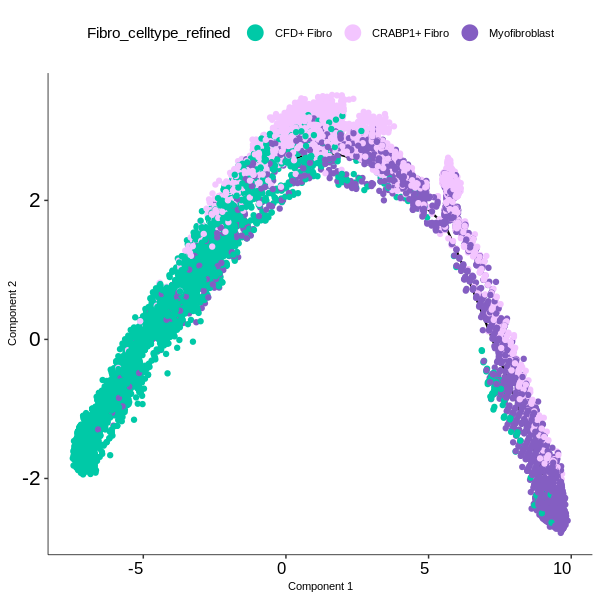

In [77]:
options(repr.plot.height=6, repr.plot.width=6)
celltype_colour=c('#00C9A7','#F3C5FF','#845EC2'  )
plot_cell_trajectory(monocle_cds, color_by = "Fibro_celltype_refined",show_tree=T, show_branch_points=F, size=1) + 
scale_color_manual(values = celltype_colour)  + 
theme(legend.text = element_text(size = 8)) + guides(color = guide_legend(override.aes = list(size = 5)))

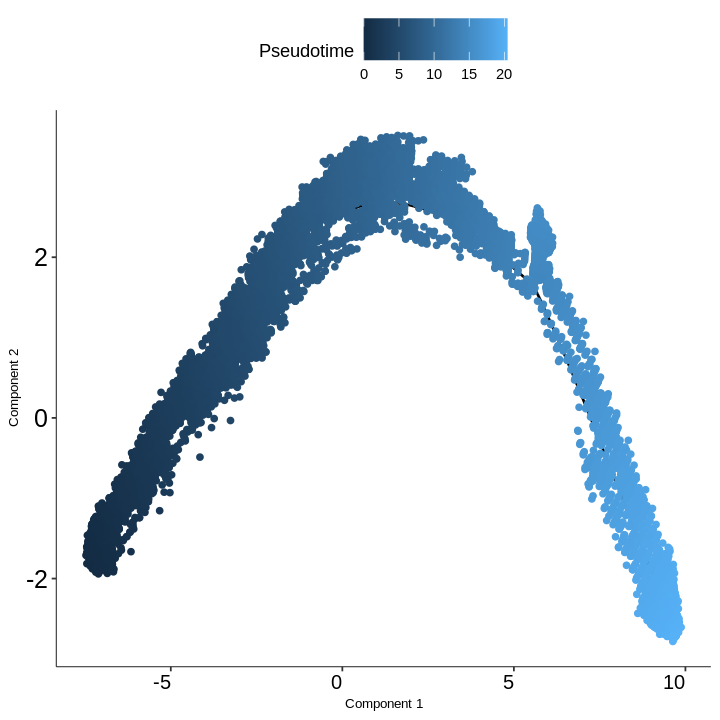

In [9]:
options(repr.plot.height=6, repr.plot.width=6)
plot_cell_trajectory(monocle_cds, color_by = "Pseudotime",show_tree=T, show_branch_points=F, size=2) + 
scale_fill_gradientn(colors = brewer.pal(9, "Purples"))

In [70]:
options(repr.plot.height=7, repr.plot.width=9)

Picking joint bandwidth of 0.493

Picking joint bandwidth of 0.493



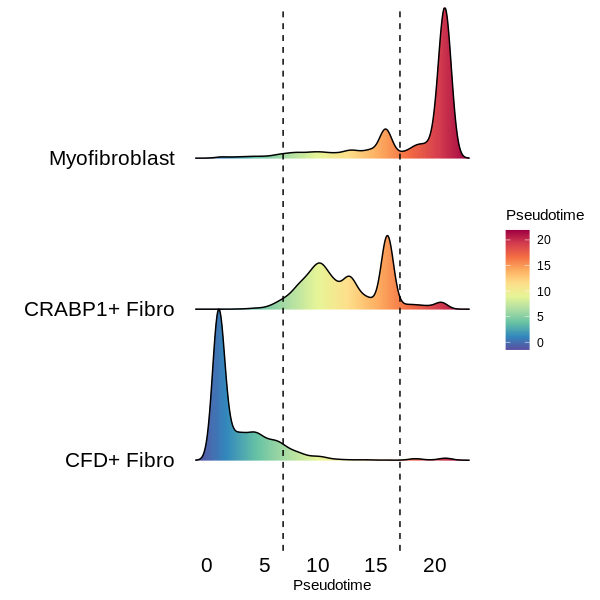

In [81]:
ggplot(pdata, aes(x=Pseudotime,y=Fibro_celltype_refined, fill = stat(x))) +
  geom_density_ridges_gradient(scale=1) +
  geom_vline(xintercept = c(6, 16),linetype=2)+
  scale_fill_gradientn(name="Pseudotime",colors = colorRampPalette(rev(brewer.pal(10, "Spectral")))(99))+
  scale_y_discrete("")+
  theme_minimal()+
  theme(
    panel.grid = element_blank(),axis.text.x = element_text(angle = 0, vjust = 1, hjust = 1,size = 15, colour = '#000000'), 
      axis.text.y = element_text(,size = 15, colour = '#000000'), 
  )